# Mohammad Amin Kiani 4043644008

## pc eng - AI 404

### EA-ex3 . ui.ac.ir

***Cell 0 — Mount Drive + Imports***

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except:
    display = print

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)


Mounted at /content/drive


***Cell 1 — Load MovieLens 100K files***

In [2]:
DATA_DIR = "/content/drive/MyDrive/Movielens_DataSet"
os.listdir(DATA_DIR)

ratings = pd.read_csv(
    f"{DATA_DIR}/u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

users = pd.read_csv(
    f"{DATA_DIR}/u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip_code"]
)

items_raw = pd.read_csv(
    f"{DATA_DIR}/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

# u.item: first 5 fields + 19 genre flags
item_cols = ["movie_id", "title", "release_date", "video_release_date", "imdb_url"] + [f"g{i}" for i in range(19)]
items_raw.columns = item_cols

genres = pd.read_csv(
    f"{DATA_DIR}/u.genre",
    sep="|",
    names=["genre", "genre_id"]
)

# Clean u.genre (drop possible empty last line)
genres_clean = genres.dropna(subset=["genre", "genre_id"]).copy()
genres_clean["genre_id"] = genres_clean["genre_id"].astype(int)
genres_clean = genres_clean.sort_values("genre_id").reset_index(drop=True)

display(ratings.head())
display(users.head())
display(items_raw.head())
display(genres_clean)


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


,movie_id,title,release_date,video_release_date,imdb_url,g0,g1,g2,g3,g4,...,g9,g10,g11,g12,g13,g14,g15,g16,g17,g18
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


,genre,genre_id
0,unknown,0
1,Action,1
2,Adventure,2
3,Animation,3
4,Children's,4
5,Comedy,5
6,Crime,6
7,Documentary,7
8,Drama,8
9,Fantasy,9


***Cell 2 — Build item→genre mapping + merge into ratings + save processed***

In [3]:
# Build: item_id -> list of genre_ids
def get_genre_ids_from_row(row):
    return [i for i in range(19) if int(row[f"g{i}"]) == 1]

movie_genres_df = items_raw[["movie_id"] + [f"g{i}" for i in range(19)]].copy()
movie_genres_df["genre_ids"] = movie_genres_df.apply(get_genre_ids_from_row, axis=1)
movie_genres_df = movie_genres_df.rename(columns={"movie_id": "item_id"})[["item_id", "genre_ids"]]

ratings_with_genres = ratings.merge(movie_genres_df, on="item_id", how="left")
ratings_exploded = ratings_with_genres.explode("genre_ids").rename(columns={"genre_ids": "genre_id"})

print("ratings_with_genres:", ratings_with_genres.shape)
print("ratings_exploded   :", ratings_exploded.shape)
display(ratings_with_genres.head())
display(ratings_exploded.head())

# Save processed
PROCESSED_DIR = "/content/drive/MyDrive/Movielens_DataSet/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

ratings_with_genres.to_csv(os.path.join(PROCESSED_DIR, "ratings_with_genres.csv"), index=False)
ratings_exploded.to_csv(os.path.join(PROCESSED_DIR, "ratings_exploded.csv"), index=False)

print("✅ Saved processed to:", PROCESSED_DIR)


ratings_with_genres: (100000, 5)
ratings_exploded   : (212595, 5)


,user_id,item_id,rating,timestamp,genre_ids
0,196,242,3,881250949,[5]
1,186,302,3,891717742,"[6, 10, 13, 16]"
2,22,377,1,878887116,"[4, 5]"
3,244,51,2,880606923,"[8, 14, 17, 18]"
4,166,346,1,886397596,"[6, 8]"


,user_id,item_id,rating,timestamp,genre_id
0,196,242,3,881250949,5
1,186,302,3,891717742,6
1,186,302,3,891717742,10
1,186,302,3,891717742,13
1,186,302,3,891717742,16


✅ Saved processed to: /content/drive/MyDrive/Movielens_DataSet/processed


***Cell 3 — Per-user time-aware split (train/val/test) + save splits***

In [4]:
SPLITS_DIR = "/content/drive/MyDrive/Movielens_DataSet/splits_mf"
os.makedirs(SPLITS_DIR, exist_ok=True)

TEST_FRAC = 0.10
VAL_FRAC  = 0.20

MIN_RATINGS_PER_USER = 5
MIN_TEST_PER_USER = 10
MIN_VAL_PER_USER  = 5

def per_user_split(df, user_col="user_id", time_col="timestamp",
                   test_frac=0.10, val_frac=0.20, random_state=42,
                   min_ratings_per_user=5, min_test_per_user=1, min_val_per_user=1,
                   time_aware=True):
    rng_local = np.random.default_rng(random_state)
    train_parts, val_parts, test_parts = [], [], []

    for uid, g in df.groupby(user_col, sort=False):
        g = g.copy()
        n = len(g)

        if n < min_ratings_per_user:
            train_parts.append(g)
            continue

        n_test = max(min_test_per_user, int(round(n * test_frac)))
        n_val  = max(min_val_per_user,  int(round(n * val_frac)))

        if n_test + n_val >= n:
            n_test = min(n_test, n - 1)
            n_val  = min(n_val,  n - 1 - n_test)

        if time_aware and time_col in g.columns:
            g = g.sort_values(time_col)
            test = g.iloc[-n_test:] if n_test > 0 else g.iloc[0:0]
            remain = g.iloc[: n - n_test]
            val = remain.iloc[-n_val:] if n_val > 0 else remain.iloc[0:0]
            train = remain.iloc[: len(remain) - len(val)]
        else:
            idx = np.arange(n)
            rng_local.shuffle(idx)
            test_idx = idx[:n_test]
            val_idx  = idx[n_test:n_test+n_val]
            train_idx = idx[n_test+n_val:]
            test = g.iloc[test_idx]
            val  = g.iloc[val_idx]
            train = g.iloc[train_idx]

        train_parts.append(train)
        val_parts.append(val)
        test_parts.append(test)

    return (
        pd.concat(train_parts, ignore_index=True),
        pd.concat(val_parts,   ignore_index=True),
        pd.concat(test_parts,  ignore_index=True),
    )

rw_train, rw_val, rw_test = per_user_split(
    ratings_with_genres,
    test_frac=TEST_FRAC,
    val_frac=VAL_FRAC,
    random_state=RANDOM_STATE,
    min_ratings_per_user=MIN_RATINGS_PER_USER,
    min_test_per_user=MIN_TEST_PER_USER,
    min_val_per_user=MIN_VAL_PER_USER,
    time_aware=True
)

# Make exploded splits consistent with base splits
key_cols = ["user_id", "item_id", "timestamp"]

def filter_exploded(exploded_df, base_split_df):
    keys = base_split_df[key_cols].drop_duplicates()
    return exploded_df.merge(keys, on=key_cols, how="inner")

re_train = filter_exploded(ratings_exploded, rw_train)
re_val   = filter_exploded(ratings_exploded, rw_val)
re_test  = filter_exploded(ratings_exploded, rw_test)

# Save
rw_train.to_csv(os.path.join(SPLITS_DIR, "ratings_with_genres_train.csv"), index=False)
rw_val.to_csv(os.path.join(SPLITS_DIR, "ratings_with_genres_val.csv"), index=False)
rw_test.to_csv(os.path.join(SPLITS_DIR, "ratings_with_genres_test.csv"), index=False)

re_train.to_csv(os.path.join(SPLITS_DIR, "ratings_exploded_train.csv"), index=False)
re_val.to_csv(os.path.join(SPLITS_DIR, "ratings_exploded_val.csv"), index=False)
re_test.to_csv(os.path.join(SPLITS_DIR, "ratings_exploded_test.csv"), index=False)

print("✅ Saved splits to:", SPLITS_DIR)
print("train/val/test:", rw_train.shape, rw_val.shape, rw_test.shape)

train_users = set(rw_train["user_id"].unique())
test_users  = set(rw_test["user_id"].unique())
print("Cold-start users in test (should be 0):", len(test_users - train_users))


✅ Saved splits to: /content/drive/MyDrive/Movielens_DataSet/splits_mf
train/val/test: (66680, 5) (20079, 5) (13241, 5)
Cold-start users in test (should be 0): 0


***Cell 4 — MF (NumPy SGD) + RMSE/MAE***

In [5]:
from math import sqrt

# MF hyperparams
n_factors = 128
n_epochs  = 50
lr        = 0.01
reg       = 0.02
seed      = 42

def rmse_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    return float(np.sqrt(mse)), float(mae)

train = rw_train[["user_id","item_id","rating"]].copy()
val   = rw_val[["user_id","item_id","rating"]].copy()
test  = rw_test[["user_id","item_id","rating"]].copy()

# Build mappings from TRAIN
user_ids = train["user_id"].unique()
item_ids = train["item_id"].unique()
user2idx = {u:i for i,u in enumerate(user_ids)}
item2idx = {m:i for i,m in enumerate(item_ids)}

n_users = len(user2idx)
n_items = len(item2idx)

# Filter val/test to only ids seen in train
val_f = val[val["user_id"].isin(user2idx) & val["item_id"].isin(item2idx)].copy()
test_f = test[test["user_id"].isin(user2idx) & test["item_id"].isin(item2idx)].copy()

def to_idx(df):
    u = df["user_id"].map(user2idx).to_numpy(dtype=np.int32)
    i = df["item_id"].map(item2idx).to_numpy(dtype=np.int32)
    r = df["rating"].to_numpy(dtype=np.float32)
    return u, i, r

u_train, i_train, r_train = to_idx(train)
u_val, i_val, r_val       = to_idx(val_f)  if len(val_f)  else (np.array([],np.int32), np.array([],np.int32), np.array([],np.float32))
u_test, i_test, r_test    = to_idx(test_f) if len(test_f) else (np.array([],np.int32), np.array([],np.int32), np.array([],np.float32))

rng_mf = np.random.default_rng(seed)
P = 0.1 * rng_mf.standard_normal((n_users, n_factors)).astype(np.float32)
Q = 0.1 * rng_mf.standard_normal((n_items, n_factors)).astype(np.float32)
bu = np.zeros(n_users, dtype=np.float32)
bi = np.zeros(n_items, dtype=np.float32)
mu = np.mean(r_train).astype(np.float32)

def predict_idx(u_idx, i_idx):
    return mu + bu[u_idx] + bi[i_idx] + np.sum(P[u_idx] * Q[i_idx], axis=1)

print(f"Training MF: users={n_users}, items={n_items}, factors={n_factors}")
for epoch in range(1, n_epochs + 1):
    perm = rng_mf.permutation(len(r_train))
    u_sh, i_sh, r_sh = u_train[perm], i_train[perm], r_train[perm]

    for u, it, r in zip(u_sh, i_sh, r_sh):
        pred = mu + bu[u] + bi[it] + np.dot(P[u], Q[it])
        err = r - pred

        pu = P[u].copy()
        qi = Q[it].copy()

        bu[u] += lr * (err - reg * bu[u])
        bi[it] += lr * (err - reg * bi[it])
        P[u]  += lr * (err * qi - reg * pu)
        Q[it] += lr * (err * pu - reg * qi)

    tr_pred = predict_idx(u_train, i_train)
    tr_rmse, tr_mae = rmse_mae(r_train, tr_pred)

    if len(r_val):
        va_pred = predict_idx(u_val, i_val)
        va_rmse, va_mae = rmse_mae(r_val, va_pred)
        print(f"Epoch {epoch:02d}: Train RMSE={tr_rmse:.4f} MAE={tr_mae:.4f} | Val RMSE={va_rmse:.4f} MAE={va_mae:.4f}")
    else:
        print(f"Epoch {epoch:02d}: Train RMSE={tr_rmse:.4f} MAE={tr_mae:.4f} | Val: (no overlap)")

if len(r_test):
    te_pred = predict_idx(u_test, i_test)
    te_rmse, te_mae = rmse_mae(r_test, te_pred)
    print(f"\nFinal TEST: RMSE={te_rmse:.4f} MAE={te_mae:.4f}  (on {len(r_test)} interactions)")
else:
    print("\nFinal TEST: (no overlap)")


Training MF: users=943, items=1573, factors=128
Epoch 01: Train RMSE=0.9359 MAE=0.7454 | Val RMSE=1.0463 MAE=0.8348
Epoch 02: Train RMSE=0.8946 MAE=0.7092 | Val RMSE=1.0204 MAE=0.8099
Epoch 03: Train RMSE=0.8654 MAE=0.6854 | Val RMSE=1.0090 MAE=0.7994
Epoch 04: Train RMSE=0.8388 MAE=0.6643 | Val RMSE=1.0015 MAE=0.7930
Epoch 05: Train RMSE=0.8117 MAE=0.6427 | Val RMSE=0.9962 MAE=0.7880
Epoch 06: Train RMSE=0.7824 MAE=0.6195 | Val RMSE=0.9927 MAE=0.7848
Epoch 07: Train RMSE=0.7505 MAE=0.5944 | Val RMSE=0.9880 MAE=0.7811
Epoch 08: Train RMSE=0.7165 MAE=0.5681 | Val RMSE=0.9858 MAE=0.7791
Epoch 09: Train RMSE=0.6814 MAE=0.5406 | Val RMSE=0.9833 MAE=0.7769
Epoch 10: Train RMSE=0.6462 MAE=0.5129 | Val RMSE=0.9820 MAE=0.7758
Epoch 11: Train RMSE=0.6116 MAE=0.4857 | Val RMSE=0.9803 MAE=0.7742
Epoch 12: Train RMSE=0.5781 MAE=0.4591 | Val RMSE=0.9808 MAE=0.7743
Epoch 13: Train RMSE=0.5464 MAE=0.4343 | Val RMSE=0.9807 MAE=0.7742
Epoch 14: Train RMSE=0.5167 MAE=0.4109 | Val RMSE=0.9811 MAE=0.7745


***Cell 5 — Build candidate sets + MF baseline Top-K list (saved)***

In [6]:
N_CANDIDATES = 300
RELEVANT_THRESHOLD = 4.0
K = 10

RESULTS_DIR = "/content/drive/MyDrive/Movielens_DataSet/results_mf"
os.makedirs(RESULTS_DIR, exist_ok=True)

# seen items per user from train+val
seen = (
    pd.concat([rw_train[["user_id","item_id"]], rw_val[["user_id","item_id"]]], ignore_index=True)
    .groupby("user_id")["item_id"].apply(set).to_dict()
)

test_relevant = (
    test_f[test_f["rating"] >= RELEVANT_THRESHOLD]
    .groupby("user_id")["item_id"].apply(set).to_dict()
)

all_train_items = set(item2idx.keys())

def mf_top_n_candidates(user_id, n=N_CANDIDATES):
    if user_id not in user2idx:
        return [], np.array([], dtype=np.float32)
    uidx = user2idx[user_id]

    seen_items = seen.get(user_id, set())
    candidates = list(all_train_items - seen_items)
    if not candidates:
        return [], np.array([], dtype=np.float32)

    cand_iidx = np.array([item2idx[iid] for iid in candidates], dtype=np.int32)
    u_arr = np.full_like(cand_iidx, fill_value=uidx)
    scores = predict_idx(u_arr, cand_iidx).astype(np.float32)

    nn = min(n, len(scores))
    topn_pos = np.argpartition(-scores, kth=nn-1)[:nn]
    topn_sorted = topn_pos[np.argsort(-scores[topn_pos])]

    cands_topN = [candidates[j] for j in topn_sorted]
    scs_topN = scores[topn_sorted]
    return cands_topN, scs_topN

# Users evaluated = users who have >=1 relevant item in test
users_eval = sorted(test_relevant.keys())

# MF baseline (fair): Top-K from Top-N candidates
mf_rows = []
for uid in users_eval:
    cands, scs = mf_top_n_candidates(uid, N_CANDIDATES)
    if len(cands) < K:
        continue
    recs = cands[:K]
    rec_scores = scs[:K]
    for rank, (iid, sc) in enumerate(zip(recs, rec_scores), start=1):
        mf_rows.append({"user_id": int(uid), "item_id": int(iid), "rank": int(rank), "pred_rating": float(sc)})

mf_recs_df = pd.DataFrame(mf_rows).sort_values(["user_id","rank"])
mf_path = os.path.join(RESULTS_DIR, f"mf_top{K}_from_top{N_CANDIDATES}_candidates.csv")
mf_recs_df.to_csv(mf_path, index=False)
print("✅ Saved MF baseline recs:", mf_path)
display(mf_recs_df.head())


✅ Saved MF baseline recs: /content/drive/MyDrive/Movielens_DataSet/results_mf/mf_top10_from_top300_candidates.csv


,user_id,item_id,rank,pred_rating
0,1,511,1,5.398755
1,1,302,2,5.305768
2,1,357,3,5.225549
3,1,709,4,5.128717
4,1,318,5,5.075803


***Cell 6 — Genre helpers (ILD, constraint checks)***

In [7]:
item_genres = {}
for _, row in items_raw.iterrows():
    iid = int(row["movie_id"])
    vec = row[[f"g{i}" for i in range(19)]].to_numpy(dtype=np.int8)
    item_genres[iid] = vec

genre_name = dict(zip(genres_clean["genre_id"].astype(int), genres_clean["genre"].astype(str)))

def jaccard_distance(vec_a, vec_b):
    inter = np.sum((vec_a == 1) & (vec_b == 1))
    union = np.sum((vec_a == 1) | (vec_b == 1))
    return 0.0 if union == 0 else 1.0 - (inter / union)

def intra_list_diversity(item_list):
    if len(item_list) < 2:
        return 0.0
    vecs = [item_genres.get(int(i)) for i in item_list]
    vecs = [v for v in vecs if v is not None]
    n = len(vecs)
    if n < 2:
        return 0.0
    s, cnt = 0.0, 0
    for i in range(n):
        for j in range(i+1, n):
            s += jaccard_distance(vecs[i], vecs[j])
            cnt += 1
    return s / cnt if cnt else 0.0

def count_distinct_genres(item_list):
    gset = set()
    for iid in item_list:
        v = item_genres.get(int(iid))
        if v is None:
            continue
        gset |= set(np.where(v == 1)[0].tolist())
    return len(gset)

def genres_of_item(iid):
    v = item_genres.get(int(iid))
    if v is None:
        return []
    return [genre_name.get(int(g), str(g)) for g in np.where(v == 1)[0]]


# ***Cell 7 — ✅ STUDENT CELL: EA multi-objective algorithm must be implemented here***

***Students must output a list of K item_ids per user based on MF predicted scores + genres, optimizing accuracy + diversity with a category constraint.***

In [ ]:
# This is a sample of PSO implementation

# ============================================================
# PSO multi-objective recommender (score + diversity + constraint)
# ============================================================

def ea_PSO_recommend_for_user(user_id, candidates, scores, K, item_genres):
    """
    Discrete PSO for recommendation list selection.

    Objectives (maximize):
      1) mean predicted rating (from MF scores)
      2) ILD diversity (genre Jaccard distance)

    Constraint:
      - at least MIN_DISTINCT_GENRES distinct genres in the recommended list

    Output:
      - list of K unique item_ids from candidates
    """

    # -------------------------
    # Hyperparameters (can be changed)
    # -------------------------
    N_PARTICLES = 50
    N_ITERS     = 50
    W_INERTIA   = 0.72
    C1          = 1.49
    C2          = 1.49

    W_SCORE = 0.8   # weight for accuracy
    W_ILD   = 0.2   # weight for diversity

    MIN_DISTINCT_GENRES = 3
    PENALTY_LAMBDA = 2.0   # bigger = stronger constraint enforcement

    # -------------------------
    # Edge cases
    # -------------------------
    nC = len(candidates)
    if nC <= K:
        # return all candidates (unique) if not enough
        return list(dict.fromkeys(candidates))[:K]

    scores = np.asarray(scores, dtype=np.float32)
    s_min, s_max = float(scores.min()), float(scores.max())
    s_rng = (s_max - s_min) if (s_max > s_min) else 1.0

    # Pre-fetch genre vectors for candidates for faster evaluation
    cand_genres = []
    for iid in candidates:
        v = item_genres.get(int(iid))
        if v is None:
            v = np.zeros(19, dtype=np.int8)
        cand_genres.append(v.astype(np.int8))
    cand_genres = np.stack(cand_genres, axis=0)  # (nC, 19)

    # -------------------------
    # Helpers
    # -------------------------
    def repair_to_k_unique(x):
        """Round/clip indices and enforce exactly K unique indices."""
        idx = np.clip(np.rint(x).astype(np.int32), 0, nC - 1)

        uniq = []
        used = set()
        for t in idx:
            t = int(t)
            if t not in used:
                uniq.append(t)
                used.add(t)
            if len(uniq) == K:
                break

        if len(uniq) < K:
            pool = [i for i in range(nC) if i not in used]
            need = K - len(uniq)
            if len(pool) >= need:
                fill = rng.choice(pool, size=need, replace=False).tolist()
            else:
                fill = rng.choice(pool if pool else np.arange(nC), size=need, replace=True).tolist()
            uniq.extend(fill)

        return np.array(uniq[:K], dtype=np.int32)

    def distinct_genres_count(idxs):
        """Count distinct genres present in selected items."""
        g_union = np.any(cand_genres[idxs] == 1, axis=0)
        return int(np.sum(g_union))

    def ild_of_indices(idxs):
        """ILD = average pairwise Jaccard distance among selected items."""
        if len(idxs) < 2:
            return 0.0
        vecs = cand_genres[idxs]  # (K, 19)
        s = 0.0
        cnt = 0
        for i in range(len(idxs)):
            for j in range(i + 1, len(idxs)):
                a = vecs[i]
                b = vecs[j]
                inter = np.sum((a == 1) & (b == 1))
                union = np.sum((a == 1) | (b == 1))
                dist = 0.0 if union == 0 else 1.0 - (inter / union)
                s += dist
                cnt += 1
        return float(s / cnt) if cnt > 0 else 0.0

    def enforce_genre_constraint(idxs):
        """
        Greedy repair: if distinct genres < MIN_DISTINCT_GENRES,
        replace low-score items with candidates that add new genres.
        """
        idxs = idxs.copy()
        chosen = set(map(int, idxs.tolist()))

        # current genre union
        g_union = np.any(cand_genres[idxs] == 1, axis=0)

        def score_of(i):  # i is candidate index
            return float(scores[i])

        # sort selected indices by score ascending (replace worst first)
        replace_order = sorted(idxs.tolist(), key=score_of)

        attempts = 0
        while int(np.sum(g_union)) < MIN_DISTINCT_GENRES and attempts < 200:
            attempts += 1

            # find a candidate not chosen that adds at least one new genre
            not_chosen = [i for i in range(nC) if i not in chosen]
            if not not_chosen:
                break

            # candidates that add new genres
            adders = []
            for j in not_chosen:
                v = cand_genres[j]
                if np.any((v == 1) & (~g_union)):
                    adders.append(j)

            if not adders:
                break

            # pick the best adder by score (you can also mix diversity here)
            best_new = max(adders, key=score_of)

            # replace one worst item
            if not replace_order:
                break
            worst = replace_order.pop(0)

            # execute replacement
            chosen.remove(int(worst))
            chosen.add(int(best_new))

            # update idxs and union
            idxs = np.array(list(chosen), dtype=np.int32)
            # re-trim to exactly K (should stay K)
            if len(idxs) > K:
                # drop lowest score extras
                idxs = np.array(sorted(idxs.tolist(), key=score_of, reverse=True)[:K], dtype=np.int32)
                chosen = set(map(int, idxs.tolist()))
            g_union = np.any(cand_genres[idxs] == 1, axis=0)

        # ensure exactly K
        if len(idxs) != K:
            # fill with highest-score unseen
            pool = [i for i in range(nC) if i not in chosen]
            pool_sorted = sorted(pool, key=lambda i: float(scores[i]), reverse=True)
            while len(idxs) < K and pool_sorted:
                j = pool_sorted.pop(0)
                chosen.add(int(j))
                idxs = np.array(list(chosen), dtype=np.int32)
            if len(idxs) > K:
                idxs = np.array(sorted(idxs.tolist(), key=score_of, reverse=True)[:K], dtype=np.int32)

        return idxs

    def objective(idxs):
        """
        Minimize: -(W_SCORE * score_norm + W_ILD * ild) + penalty
        """
        mean_score = float(np.mean(scores[idxs]))
        mean_score_norm = (mean_score - s_min) / s_rng  # [0,1] approx
        ild = ild_of_indices(idxs)                       # [0,1]

        distinct = distinct_genres_count(idxs)
        viol = max(0, MIN_DISTINCT_GENRES - distinct)
        penalty = PENALTY_LAMBDA * (viol ** 2)

        # maximize => minimize negative
        return - (W_SCORE * mean_score_norm + W_ILD * ild) + penalty

    # -------------------------
    # Initialize PSO particles
    # -------------------------
    X = np.zeros((N_PARTICLES, K), dtype=np.float32)
    V = np.zeros((N_PARTICLES, K), dtype=np.float32)

    for p in range(N_PARTICLES):
        X[p] = rng.choice(np.arange(nC), size=K, replace=False).astype(np.float32)

    pbest_X = X.copy()
    pbest_f = np.full(N_PARTICLES, np.inf, dtype=np.float32)

    gbest_X = None
    gbest_f = np.inf

    # Evaluate initial
    for p in range(N_PARTICLES):
        idxs = enforce_genre_constraint(repair_to_k_unique(X[p]))
        f = objective(idxs)
        pbest_f[p] = f
        pbest_X[p] = idxs.astype(np.float32)
        if f < gbest_f:
            gbest_f = f
            gbest_X = idxs.astype(np.float32)

    # -------------------------
    # PSO loop
    # -------------------------
    for _ in range(N_ITERS):
        for p in range(N_PARTICLES):
            r1 = rng.random(K, dtype=np.float32)
            r2 = rng.random(K, dtype=np.float32)

            V[p] = (W_INERTIA * V[p]
                    + C1 * r1 * (pbest_X[p] - X[p])
                    + C2 * r2 * (gbest_X - X[p]))
            X[p] = X[p] + V[p]

            idxs = enforce_genre_constraint(repair_to_k_unique(X[p]))
            f = objective(idxs)

            if f < pbest_f[p]:
                pbest_f[p] = f
                pbest_X[p] = idxs.astype(np.float32)

                if f < gbest_f:
                    gbest_f = f
                    gbest_X = idxs.astype(np.float32)

    # -------------------------
    # Return best particle as item_ids
    # -------------------------
    best_idxs = enforce_genre_constraint(repair_to_k_unique(gbest_X))
    rec_items = [int(candidates[i]) for i in best_idxs.tolist()]

    # final safety: unique + length K
    rec_items = list(dict.fromkeys(rec_items))
    if len(rec_items) < K:
        # fill with top-score unseen candidates
        chosen = set(rec_items)
        order = np.argsort(-scores)
        for j in order:
            iid = int(candidates[int(j)])
            if iid not in chosen:
                rec_items.append(iid)
                chosen.add(iid)
            if len(rec_items) == K:
                break

    return rec_items[:K]



In [12]:
# ============================================================
# STUDENT CELL (Define your algorithm function here)
# ============================================================
'''
def ea_recommend_for_user(user_id, candidates, scores, K, item_genres, params):
    """
    Students must implement their own multi-objective EA / swarm algorithm that selects
    K unique items from the candidate pool.

    Inputs:
      user_id: int
      candidates: list[int]        # Top-N_CANDIDATES unseen items (by MF score)
      scores: np.array (float32)   # MF scores aligned with candidates
      K: int                       # final list size
      item_genres: dict[item_id] -> np.array(19,) binary genre flags
      params: dict                 # hyperparameters for the student algorithm

    Output:
      rec_list: list[int] of length K
        - unique
        - subset of candidates
        - no duplicates
    """
    raise NotImplementedError("Students must implement EA here.")

    '''
# ============================================================
# ============================================================

import numpy as np

def ea_recommend_for_user(user_id, candidates, scores, K, item_genres, params):
    """
    خروجی: لیست Kتایی از item_id (یکتا، زیرمجموعه candidates)
    پشتیبانی:
      algo: "HSA" یا "MA"
      mo_mode: "pareto" یا "weighted"
    """
    # -------------------- پارامترها --------------------
    algo    = str(params.get("algo", "HSA")).upper()
    mo_mode = str(params.get("mo_mode", "pareto")).lower()

    pop_size = int(params.get("pop_size", 50))
    iters    = int(params.get("n_gens", params.get("iters", 50)))
    seed     = int(params.get("seed", 42))

    HMCR = float(params.get("HMCR", 0.9))
    PAR  = float(params.get("PAR", 0.25))

    PC      = float(params.get("p_crossover", 0.9))
    PM      = float(params.get("p_mutation", 0.2))
    ELITE   = int(params.get("elite", 2))
    LS_PROB = float(params.get("ls_prob", 0.6))
    LS_STEPS= int(params.get("ls_steps", 10))
    TOUR_K  = int(params.get("tournament_k", 3))

    MIN_DISTINCT_GENRES = int(params.get("min_distinct_genres", 3))
    penalty_lambda      = float(params.get("penalty_lambda", 2.0))

    w_score = float(params.get("w_score", 0.7))
    w_div   = float(params.get("w_div", 0.3))
    s = w_score + w_div
    w_score, w_div = (w_score/s, w_div/s) if s > 0 else (0.7, 0.3)

    pareto_pick = str(params.get("pareto_pick", "maxsum")).lower()  # maxsum / knee
    w_pareto    = float(params.get("w_pareto", 0.5))

    rng = np.random.default_rng(seed + int(user_id))

    candidates = list(map(int, candidates))
    scores = np.asarray(scores, dtype=np.float32)
    nC = len(candidates)
    if nC <= K:
        return list(dict.fromkeys(candidates))[:K]

    # برای نرمال‌سازی دقت
    s_min, s_max = float(scores.min()), float(scores.max())
    s_rng = (s_max - s_min) if s_max > s_min else 1.0

    # ژانرهای کاندیدها
    cand_genres = []
    for iid in candidates:
        v = item_genres.get(int(iid))
        if v is None:
            v = np.zeros(19, dtype=np.int8)
        cand_genres.append(np.asarray(v, dtype=np.int8))
    cand_genres = np.stack(cand_genres, axis=0)  # (nC, 19)

    # -------------------- ابزارهای کمکی --------------------
    def repair_to_k_unique(idxs):
        idxs = np.asarray(idxs, dtype=np.int32)
        idxs = np.clip(idxs, 0, nC-1)
        uniq, used = [], set()
        for t in idxs.tolist():
            t = int(t)
            if t not in used:
                uniq.append(t); used.add(t)
            if len(uniq) == K:
                break
        if len(uniq) < K:
            pool = [i for i in range(nC) if i not in used]
            need = K - len(uniq)
            fill = rng.choice(pool, size=need, replace=False).tolist() if len(pool) >= need else rng.choice(np.arange(nC), size=need, replace=True).tolist()
            uniq.extend(fill)
        return np.array(uniq[:K], dtype=np.int32)

    def distinct_genres_count(idxs):
        g_union = np.any(cand_genres[idxs] == 1, axis=0)
        return int(np.sum(g_union))

    def violation(idxs):
        return max(0, MIN_DISTINCT_GENRES - distinct_genres_count(idxs))

    def enforce_genre_constraint(idxs):
        """Repair حریصانه: اگر ژانرها کم بود، آیتم‌های کم‌امتیاز را با آیتمی که ژانر جدید می‌آورد جایگزین کن."""
        idxs = repair_to_k_unique(idxs)
        chosen = set(map(int, idxs.tolist()))
        g_union = np.any(cand_genres[idxs] == 1, axis=0)

        def sc(j): return float(scores[j])

        replace_order = sorted(list(chosen), key=sc)  # کم‌امتیازها اول
        tries = 0
        while int(np.sum(g_union)) < MIN_DISTINCT_GENRES and tries < 300:
            tries += 1
            not_chosen = [i for i in range(nC) if i not in chosen]
            if not not_chosen:
                break
            missing_mask = ~g_union
            adders = [j for j in not_chosen if np.any((cand_genres[j] == 1) & missing_mask)]
            if not adders:
                break
            best_new = max(adders, key=sc)
            if not replace_order:
                break
            worst = replace_order.pop(0)

            chosen.remove(int(worst))
            chosen.add(int(best_new))
            idxs = np.array(list(chosen), dtype=np.int32)

            # اگر بیشتر از K شد، K تای با امتیاز بالاتر را نگه دار
            if len(idxs) > K:
                idxs = np.array(sorted(idxs.tolist(), key=sc, reverse=True)[:K], dtype=np.int32)
                chosen = set(map(int, idxs.tolist()))

            g_union = np.any(cand_genres[idxs] == 1, axis=0)

        # سایز را دقیقاً K کن
        if len(chosen) < K:
            pool = [i for i in range(nC) if i not in chosen]
            pool = sorted(pool, key=lambda j: float(scores[j]), reverse=True)
            for j in pool:
                chosen.add(int(j))
                if len(chosen) == K:
                    break
        idxs = np.array(list(chosen), dtype=np.int32)
        if len(idxs) > K:
            idxs = np.array(sorted(idxs.tolist(), key=lambda j: float(scores[j]), reverse=True)[:K], dtype=np.int32)
        return idxs

    def acc_norm(idxs):
        m = float(np.mean(scores[idxs]))
        return (m - s_min) / s_rng

    def ild(idxs):
        if len(idxs) < 2:
            return 0.0
        vecs = cand_genres[idxs]
        s = 0.0; cnt = 0
        for i in range(len(idxs)):
            for j in range(i+1, len(idxs)):
                a, b = vecs[i], vecs[j]
                inter = np.sum((a==1)&(b==1))
                uni   = np.sum((a==1)|(b==1))
                dist  = 0.0 if uni==0 else 1.0 - inter/uni
                s += dist; cnt += 1
        return float(s/cnt) if cnt else 0.0

    def weighted_obj(idxs):
        A = acc_norm(idxs)
        D = ild(idxs)
        pen = penalty_lambda * (violation(idxs)**2)
        return (w_score*A + w_div*D) - pen

    # --------- پارتو (NSGA-II ساده) ----------
    def dominates(A, B):
        return (A[0]>=B[0] and A[1]>=B[1]) and (A[0]>B[0] or A[1]>B[1])

    def fast_nondom_sort(F):
        S=[set() for _ in range(len(F))]
        n=[0]*len(F)
        fronts=[[]]
        for p in range(len(F)):
            for q in range(len(F)):
                if p==q: continue
                if dominates(F[p], F[q]): S[p].add(q)
                elif dominates(F[q], F[p]): n[p]+=1
            if n[p]==0: fronts[0].append(p)
        i=0
        while fronts[i]:
            Q=[]
            for p in fronts[i]:
                for q in S[p]:
                    n[q]-=1
                    if n[q]==0: Q.append(q)
            i+=1
            fronts.append(Q)
        return fronts[:-1]

    def crowding(front, F):
        if not front: return {}
        dist={i:0.0 for i in front}
        for obj in [0,1]:
            sf=sorted(front, key=lambda i: F[i][obj])
            dist[sf[0]]=float("inf"); dist[sf[-1]]=float("inf")
            fmin,fmax=F[sf[0]][obj],F[sf[-1]][obj]
            if abs(fmax-fmin)<1e-12:
                continue
            for j in range(1,len(sf)-1):
                dist[sf[j]] += (F[sf[j+1]][obj]-F[sf[j-1]][obj])/(fmax-fmin)
        return dist

    def nsga2_select(pop, size):
        F=[(acc_norm(x), ild(x)) for x in pop]
        fronts=fast_nondom_sort(F)
        new=[]
        for fr in fronts:
            if len(new)+len(fr)<=size:
                new.extend(fr)
            else:
                cd=crowding(fr,F)
                fr_sorted=sorted(fr, key=lambda i: cd[i], reverse=True)
                need=size-len(new)
                new.extend(fr_sorted[:need])
                break
        return [pop[i] for i in new]

    def pareto_filter(pop):
        F=[(acc_norm(x), ild(x)) for x in pop]
        keep=[]
        for i in range(len(pop)):
            dom=False
            for j in range(len(pop)):
                if i!=j and dominates(F[j], F[i]):
                    dom=True; break
            if not dom:
                keep.append(i)
        return [pop[i] for i in keep]

    def pick_one(front):
        # چون نوت‌بوک فقط یک لیست می‌خواهد
        F=[(acc_norm(x), ild(x)) for x in front]
        f1=np.array([t[0] for t in F], float)
        f2=np.array([t[1] for t in F], float)
        f1n=(f1-f1.min())/(f1.max()-f1.min()+1e-9)
        f2n=(f2-f2.min())/(f2.max()-f2.min()+1e-9)
        if pareto_pick=="knee":
            d=(1-f1n)**2+(1-f2n)**2
            return front[int(np.argmin(d))]
        else:
            s = w_pareto*f1n + (1-w_pareto)*f2n
            return front[int(np.argmax(s))]

    # --------- عملگرها ----------
    def random_sol():
        idxs = rng.choice(np.arange(nC), size=K, replace=False)
        return enforce_genre_constraint(idxs)

    # HSA: تولید harmony جدید با HMCR/PAR
    def hsa_improvise(HM):
        chosen=[]; used=set()
        for pos in range(K):
            if len(HM)>0 and rng.random()<HMCR:
                h = HM[int(rng.integers(0,len(HM)))]
                item=int(h[pos])
                if item in used:
                    pool=[i for i in range(nC) if i not in used]
                    item=int(rng.choice(pool))
                if rng.random()<PAR:
                    pool=[i for i in range(nC) if i not in used]
                    if pool:
                        item=int(rng.choice(pool))
            else:
                pool=[i for i in range(nC) if i not in used]
                item=int(rng.choice(pool))
            chosen.append(item); used.add(item)
        return enforce_genre_constraint(chosen)

    def crossover(p1,p2):
        cut=int(rng.integers(1,K))
        head=list(p1[:cut])
        tail=[x for x in p2.tolist() if x not in head]
        child=np.array((head+tail)[:K], dtype=np.int32)
        return enforce_genre_constraint(child)

    def mutate(sol):
        sol=sol.copy()
        if rng.random()<PM:
            pos=int(rng.integers(0,K))
            pool=[i for i in range(nC) if i not in sol]
            if pool:
                sol[pos]=int(rng.choice(pool))
        return enforce_genre_constraint(sol)

    def local_search(sol, mode):
        best=sol.copy()
        bestF=(acc_norm(best), ild(best))
        for _ in range(LS_STEPS):
            pool=[i for i in range(nC) if i not in best]
            if not pool: break
            pos=int(rng.integers(0,K))
            new_item=int(rng.choice(pool))
            neigh=best.copy()
            neigh[pos]=new_item
            neigh=enforce_genre_constraint(neigh)
            F=(acc_norm(neigh), ild(neigh))
            if mode=="weighted":
                if weighted_obj(neigh) > weighted_obj(best):
                    best=neigh; bestF=F
            else:
                if dominates(F, bestF):
                    best=neigh; bestF=F
        return best

    def tournament(pop, fit):
        k=max(2, TOUR_K)
        idxs=rng.choice(np.arange(len(pop)), size=k, replace=False)
        b=int(idxs[0])
        for i in idxs[1:]:
            i=int(i)
            if fit[i] > fit[b]:
                b=i
        return pop[b]

    # -------------------- اجرای الگوریتم --------------------
    if algo == "HSA":
        HM=[random_sol() for _ in range(pop_size)]
        if mo_mode=="weighted":
            for _ in range(iters):
                x_new=hsa_improvise(HM)
                pop=HM+[x_new]
                fit=np.array([weighted_obj(x) for x in pop], float)
                keep=np.argsort(fit)[::-1][:pop_size]
                HM=[pop[int(i)] for i in keep]
            best=max(HM, key=lambda x: weighted_obj(x))
        else:
            archive=HM.copy()
            for _ in range(iters):
                x_new=hsa_improvise(HM)
                archive.append(x_new)
                archive=pareto_filter(archive)
                if len(archive)>pop_size:
                    archive=nsga2_select(archive, pop_size)
                HM=archive.copy()
            best=pick_one(archive)

    else:  # MA
        pop=[random_sol() for _ in range(pop_size)]
        if mo_mode=="weighted":
            for _ in range(iters):
                fit=np.array([weighted_obj(x) for x in pop], float)
                elite_idx=np.argsort(fit)[::-1][:max(0,ELITE)]
                elites=[pop[int(i)].copy() for i in elite_idx]
                offspring=[]
                while len(offspring) < pop_size - len(elites):
                    p1=tournament(pop, fit)
                    p2=tournament(pop, fit)
                    c = crossover(p1,p2) if rng.random()<PC else p1.copy()
                    c = mutate(c)
                    if rng.random()<LS_PROB:
                        c = local_search(c, mode="weighted")
                    offspring.append(c)
                pop = (elites + offspring)[:pop_size]
            best=max(pop, key=lambda x: weighted_obj(x))
        else:
            archive=pop.copy()
            for _ in range(iters):
                offspring=[]
                while len(offspring) < pop_size:
                    a,b=rng.choice(pop, size=2, replace=False)
                    c1=crossover(a,b) if rng.random()<PC else a.copy()
                    c2=crossover(b,a) if rng.random()<PC else b.copy()
                    c1=mutate(c1); c2=mutate(c2)
                    if rng.random()<LS_PROB: c1=local_search(c1, mode="pareto")
                    if rng.random()<LS_PROB: c2=local_search(c2, mode="pareto")
                    offspring.append(c1)
                    if len(offspring)<pop_size:
                        offspring.append(c2)
                combined=pop+offspring
                pop=nsga2_select(combined, pop_size)
                archive += pop
                archive = pareto_filter(archive)
                if len(archive)>pop_size:
                    archive=nsga2_select(archive, pop_size)
            best=pick_one(archive)

    best = enforce_genre_constraint(best)
    rec=[int(candidates[int(i)]) for i in best.tolist()]
    rec=list(dict.fromkeys(rec))
    if len(rec)<K:
        chosen=set(rec)
        order=np.argsort(-scores)
        for j in order:
            iid=int(candidates[int(j)])
            if iid not in chosen:
                rec.append(iid); chosen.add(iid)
            if len(rec)==K:
                break
    return rec[:K]



algo="HSA", mo_mode="pareto"

algo="HSA", mo_mode="weighted"

algo="MA", mo_mode="pareto"

algo="MA", mo_mode="weighted"

In [13]:
# ============================================================
# STUDENT HYPERPARAMETERS (Define your hyperparameters here)
# ============================================================
# Top-k items
K=10
MIN_DISTINCT_GENRES = 3

EA_PARAMS = {
    # --- fairness ثابت ---
    "seed": 42,
    "pop_size": 50,
    "n_gens": 50,                # تعداد تکرار/نسل برای هر دو الگوریتم یکسان
    "min_distinct_genres": MIN_DISTINCT_GENRES,

    # --- multi-objective ---
    "mo_mode": "pareto",         # یا "weighted"
    "w_score": 0.7,
    "w_div": 0.3,
    "penalty_lambda": 2.0,
    "pareto_pick": "maxsum",     # maxsum یا knee
    "w_pareto": 0.5,

    # --- HSA ---
    "algo": "HSA",
    "HMCR": 0.9,
    "PAR": 0.25,

    # --- MA ---
    "p_crossover": 0.9,
    "p_mutation": 0.2,
    "tournament_k": 3,
    "elite": 2,
    "ls_prob": 0.6,
    "ls_steps": 10,
}


### ***Cell 8 — Run EA for all users and create recommendation file (uses your EA function)***

***Define your main run cell below. Students must edit or rewrite their main below to run the algorithm.***

In [14]:
from tqdm.auto import tqdm
import os, time
import numpy as np
import pandas as pd

EA_RESULTS_DIR = "/content/drive/MyDrive/Movielens_DataSet/results_ea"
os.makedirs(EA_RESULTS_DIR, exist_ok=True)

def run_one_setting(algo_name, mo_mode):
    # تنظیم الگوریتم/حالت
    EA_PARAMS["algo"] = algo_name
    EA_PARAMS["mo_mode"] = mo_mode

    out_path = os.path.join(
        EA_RESULTS_DIR,
        f"ea_{algo_name}_{mo_mode}_top{K}_from_top{N_CANDIDATES}_candidates.csv"
    )

    ea_rows = []
    per_user_times = []
    t_total0 = time.time()

    for uid in tqdm(users_eval, desc=f"EA={algo_name},{mo_mode}", unit="user"):
        t0 = time.time()

        candidates, scores = mf_top_n_candidates(uid, N_CANDIDATES)
        if len(candidates) < K:
            continue

        #  params را پاس می‌دهیم
        rec_list = ea_recommend_for_user(uid, candidates, scores, K, item_genres, EA_PARAMS)

        # Safety checks
        assert isinstance(rec_list, list), "EA output must be a list"
        assert len(rec_list) == K, f"EA must return exactly K={K} items"
        assert len(set(rec_list)) == K, "EA list must not contain duplicates"
        assert set(rec_list).issubset(set(candidates)), "EA list must be subset of candidates"

        score_map = {int(it): float(sc) for it, sc in zip(candidates, scores)}
        for rank, iid in enumerate(rec_list, start=1):
            ea_rows.append({
                "user_id": int(uid),
                "item_id": int(iid),
                "rank": int(rank),
                "pred_rating": float(score_map.get(int(iid), np.nan))
            })

        per_user_times.append(time.time() - t0)

    t_total = time.time() - t_total0
    print("\n=== Runtime ===")
    print(f"Setting: {algo_name} / {mo_mode}")
    print(f"Total runtime: {t_total:.2f}s  | users: {len(per_user_times)} | avg/user: {np.mean(per_user_times):.4f}s")

    df = pd.DataFrame(ea_rows).sort_values(["user_id","rank"])
    df.to_csv(out_path, index=False)
    print("✅ Saved:", out_path)
    return out_path, df

# ---- چهار اجرای استاندارد (همزمان/پشت سر هم) ----
paths = {}
dfs = {}

for algo_name in ["HSA", "MA"]:
    for mo_mode in ["pareto", "weighted"]:
        p, d = run_one_setting(algo_name, mo_mode)
        paths[(algo_name, mo_mode)] = p
        dfs[(algo_name, mo_mode)] = d

# خروجی‌ها آماده‌اند
paths


EA=HSA,pareto:   0%|          | 0/916 [00:00<?, ?user/s]


=== Runtime ===
Setting: HSA / pareto
Total runtime: 335.79s  | users: 916 | avg/user: 0.3656s
✅ Saved: /content/drive/MyDrive/Movielens_DataSet/results_ea/ea_HSA_pareto_top10_from_top300_candidates.csv


EA=HSA,weighted:   0%|          | 0/916 [00:00<?, ?user/s]


=== Runtime ===
Setting: HSA / weighted
Total runtime: 2339.66s  | users: 916 | avg/user: 2.5533s
✅ Saved: /content/drive/MyDrive/Movielens_DataSet/results_ea/ea_HSA_weighted_top10_from_top300_candidates.csv


EA=MA,pareto:   0%|          | 0/916 [00:00<?, ?user/s]

KeyboardInterrupt: 

علت کندتر شدن وزن دار این است که در آن مرتب ارزش محاسبه و مرتب‌سازی می‌شود و جریمه هم هست.

In [15]:
# 2) اجرای MA جداگانه
for mo_mode in ["pareto", "weighted"]:
    p, d = run_one_setting("MA", mo_mode)
    paths[("MA", mo_mode)] = p
    dfs[("MA", mo_mode)]   = d

paths


EA=MA,pareto:   0%|          | 0/916 [00:00<?, ?user/s]

KeyboardInterrupt: 

In [16]:

EA_PARAMS["pop_size"] = 20
EA_PARAMS["n_gens"]   = 20
EA_PARAMS["ls_steps"] = 3
EA_PARAMS["ls_prob"]  = 0.3
EA_PARAMS["elite"]    = 1

# اجرای MA جداگانه
for mo_mode in ["pareto", "weighted"]:
    p, d = run_one_setting("MA", mo_mode)
    paths[("MA", mo_mode)] = p
    dfs[("MA", mo_mode)]   = d

paths


EA=MA,pareto:   0%|          | 0/916 [00:00<?, ?user/s]


=== Runtime ===
Setting: MA / pareto
Total runtime: 2636.62s  | users: 916 | avg/user: 2.8775s
✅ Saved: /content/drive/MyDrive/Movielens_DataSet/results_ea/ea_MA_pareto_top10_from_top300_candidates.csv


EA=MA,weighted:   0%|          | 0/916 [00:00<?, ?user/s]


=== Runtime ===
Setting: MA / weighted
Total runtime: 2013.47s  | users: 916 | avg/user: 2.1973s
✅ Saved: /content/drive/MyDrive/Movielens_DataSet/results_ea/ea_MA_weighted_top10_from_top300_candidates.csv


{('HSA',
  'pareto'): '/content/drive/MyDrive/Movielens_DataSet/results_ea/ea_HSA_pareto_top10_from_top300_candidates.csv',
 ('HSA',
  'weighted'): '/content/drive/MyDrive/Movielens_DataSet/results_ea/ea_HSA_weighted_top10_from_top300_candidates.csv',
 ('MA',
  'pareto'): '/content/drive/MyDrive/Movielens_DataSet/results_ea/ea_MA_pareto_top10_from_top300_candidates.csv',
 ('MA',
  'weighted'): '/content/drive/MyDrive/Movielens_DataSet/results_ea/ea_MA_weighted_top10_from_top300_candidates.csv'}

In [ ]:
# N_CANDIDATES = 150


***Cell 9 — Evaluation (Accuracy + Diversity + Constraint check)***

In [17]:
import os
print("RESULTS_DIR =", RESULTS_DIR)
print("\nFiles:")
for fn in sorted(os.listdir(RESULTS_DIR)):
    print(" -", fn)


RESULTS_DIR = /content/drive/MyDrive/Movielens_DataSet/results_mf

Files:
 - mf_top10_from_top300_candidates.csv


In [18]:
from collections import Counter

def precision_at_k_list(lst, relevant_set, k):
    return len(set(lst[:k]) & relevant_set) / k if k > 0 else np.nan

def recall_at_k_list(lst, relevant, k):
    if len(relevant) == 0:
        return np.nan
    return len(set(lst[:k]) & relevant) / len(relevant)

def ndcg_at_k_list(lst, relevant_set, k):
    if len(relevant_set) == 0:
        return np.nan
    dcg = 0.0
    for rank, iid in enumerate(lst[:k], start=1):
        if iid in relevant_set:
            dcg += 1.0 / np.log2(rank + 1)
    ideal = min(len(relevant_set), k)
    idcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal + 1))
    return dcg / idcg if idcg > 0 else np.nan

def mrr_at_k_list(lst, relevant_set, k):
    for rank, iid in enumerate(lst[:k], start=1):
        if iid in relevant_set:
            return 1.0 / rank
    return 0.0

def gini_from_counts(counts):
    x = np.sort(np.array(list(counts), dtype=np.float64))
    if x.sum() == 0:
        return np.nan
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

def entropy_norm_from_counts(counts):
    x = np.array(list(counts), dtype=np.float64)
    if x.sum() == 0:
        return np.nan
    p = x / x.sum()
    ent = float(-(p * np.log2(p + 1e-12)).sum())
    return ent / np.log2(len(p)) if len(p) > 1 else 0.0

def evaluate_recs_df(recs_df, name, K=10, min_distinct_genres=None):
    recs_df = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K).copy()
    user_lists = recs_df.groupby("user_id")["item_id"].apply(list)

    precs, recalls, ndcgs, mrrs, ilds = [], [], [], [], []
    genre_ok = []
    exposure = Counter()

    for uid, lst in user_lists.items():
        rel = test_relevant.get(uid, set())

        precs.append(precision_at_k_list(lst, rel, K))
        recalls.append(recall_at_k_list(lst, rel, K))
        ndcgs.append(ndcg_at_k_list(lst, rel, K))
        mrrs.append(mrr_at_k_list(lst, rel, K))
        ilds.append(intra_list_diversity(lst))

        if min_distinct_genres is not None:
            genre_ok.append(count_distinct_genres(lst) >= min_distinct_genres)

        for iid in lst[:K]:
            exposure[int(iid)] += 1

    unique_items = len(exposure)
    catalog_all = items_raw["movie_id"].nunique()
    catalog_train = len(all_train_items)

    return {
        "Model": name,
        f"Precision@{K}": float(np.nanmean(precs)),
        f"Recall@{K}": float(np.nanmean(recalls)),
        f"NDCG@{K}": float(np.nanmean(ndcgs)),
        f"MRR@{K}": float(np.mean(mrrs)),
        "ILD": float(np.mean(ilds)),
        f"Coverage@{K} (train)": float(unique_items / catalog_train) if catalog_train else np.nan,
        f"Coverage@{K} (all)": float(unique_items / catalog_all) if catalog_all else np.nan,
        "Gini": float(gini_from_counts(exposure.values())),
        "Entropy_norm": float(entropy_norm_from_counts(exposure.values())),
        "Users_evaluated": int(len(user_lists)),
        "Unique_items_recommended": int(unique_items),
        "Constraint_ok_rate": float(np.mean(genre_ok)) if len(genre_ok) else np.nan
    }

# Load MF baseline and EA results (if not in memory)
# mf_recs_df = pd.read_csv(os.path.join(RESULTS_DIR, f"mf_numpy_top{K}_recs.csv"))
mf_recs_df = pd.read_csv(os.path.join(RESULTS_DIR, f"mf_top{K}_from_top{N_CANDIDATES}_candidates.csv"))
ea_recs_df = pd.read_csv(EA_RECS_PATH)

# Set your constraint threshold (or leave None if students handle it internally)
MIN_DISTINCT_GENRES = 3

# mf_metrics = evaluate_recs_df(mf_recs_df, "MF baseline", K=K, min_distinct_genres=MIN_DISTINCT_GENRES)
# ea_metrics = evaluate_recs_df(ea_recs_df, "EA (student)", K=K, min_distinct_genres=MIN_DISTINCT_GENRES)

# compare = pd.DataFrame([mf_metrics, ea_metrics])
# display(compare)

# --------------------------------------------------------------------------------------------------------

# Load MF baseline
mf_recs_df = pd.read_csv(os.path.join(RESULTS_DIR, f"mf_top{K}_from_top{N_CANDIDATES}_candidates.csv"))
# اگر فایل شما دقیقاً این است:
# mf_recs_df = pd.read_csv(os.path.join(RESULTS_DIR, f"mf_top{K}_from_top300_candidates.csv"))

# 5-row comparison: MF + (HSA/MA × pareto/weighted)
results = []
results.append(evaluate_recs_df(mf_recs_df, "MF baseline", K=K, min_distinct_genres=MIN_DISTINCT_GENRES))

for (algo_name, mo_mode), p in paths.items():
    df = pd.read_csv(p)
    results.append(evaluate_recs_df(df, f"{algo_name}-{mo_mode}", K=K, min_distinct_genres=MIN_DISTINCT_GENRES))

compare = pd.DataFrame(results)
display(compare.sort_values("ILD", ascending=False))


,Model,Precision@10,Recall@10,NDCG@10,MRR@10,ILD,Coverage@10 (train),Coverage@10 (all),Gini,Entropy_norm,Users_evaluated,Unique_items_recommended,Constraint_ok_rate
3,MA-pareto,0.017031,0.022122,0.020646,0.043345,0.940676,0.514940,0.481570,0.647300,0.884083,916,810,1.0
1,HSA-pareto,0.015175,0.017456,0.018076,0.042037,0.920432,0.568976,0.532105,0.604516,0.903679,916,895,1.0
4,MA-weighted,0.023362,0.031207,0.029602,0.066875,0.881359,0.410045,0.383472,0.663871,0.872651,916,645,1.0
2,HSA-weighted,0.016703,0.020233,0.021905,0.055706,0.863171,0.587413,0.549346,0.571875,0.917017,916,924,1.0
0,MF baseline,0.028493,0.037138,0.035428,0.077686,0.789337,0.326764,0.305589,0.674568,0.860417,916,514,1.0


# ***visualization***

***Helper functions for plotting***

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def build_user_lists(recs_df, K=10):
    recs_df = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K).copy()
    return recs_df.groupby("user_id")["item_id"].apply(list)

def precision_at_k_list(lst, relevant_set, k):
    return len(set(lst[:k]) & relevant_set) / k if k > 0 else np.nan

def recall_at_k_list(lst, relevant_set, k):
    if len(relevant_set) == 0:
        return np.nan
    return len(set(lst[:k]) & relevant_set) / len(relevant_set)

def ndcg_at_k_list(lst, relevant_set, k):
    if len(relevant_set) == 0:
        return np.nan
    dcg = 0.0
    for rank, iid in enumerate(lst[:k], start=1):
        if iid in relevant_set:
            dcg += 1.0 / np.log2(rank + 1)
    ideal = min(len(relevant_set), k)
    idcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal + 1))
    return dcg / idcg if idcg > 0 else np.nan

def mrr_at_k_list(lst, relevant_set, k):
    for rank, iid in enumerate(lst[:k], start=1):
        if iid in relevant_set:
            return 1.0 / rank
    return 0.0

def mean_pred_score_for_user(recs_df, score_col="pred_rating", K=10):
    # If pred_rating exists, use it. Otherwise return NaN.
    if score_col not in recs_df.columns:
        return pd.Series(dtype=float)
    tmp = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K)
    return tmp.groupby("user_id")[score_col].mean()

def exposure_counts(recs_df, K=10):
    tmp = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K)
    return tmp["item_id"].value_counts()

def lorenz_curve_from_counts(counts):
    x = np.sort(np.array(list(counts), dtype=np.float64))
    if x.sum() == 0:
        return np.array([0.0, 1.0])
    cum = np.cumsum(x)
    cum = np.insert(cum, 0, 0)
    return cum / cum[-1]

def coverage_curve(recs_df, catalog_items, max_k=20):
    # catalog_items = set of recommendable items (train items is fair for MF)
    cov = []
    for kk in range(1, max_k+1):
        sub = recs_df[recs_df["rank"] <= kk]
        cov.append(sub["item_id"].nunique() / len(catalog_items) if len(catalog_items) else np.nan)
    return np.array(cov, dtype=float)


***Per-user tradeoff scatter: Mean score vs ILD (MF vs EA)***

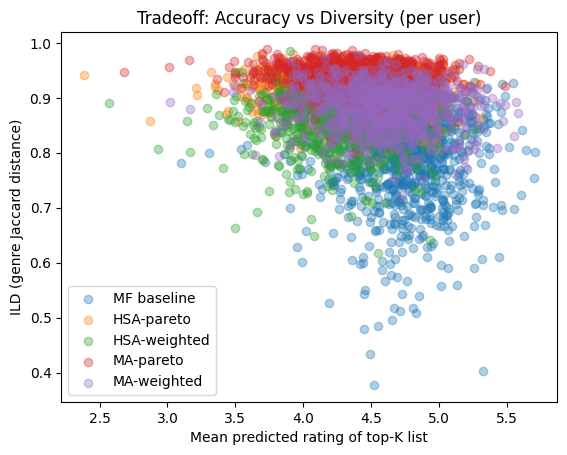

In [20]:
K = 10

# mf_lists = build_user_lists(mf_recs_df, K)
# ea_lists = build_user_lists(ea_recs_df, K)

# mf_ild = mf_lists.apply(intra_list_diversity)
# ea_ild = ea_lists.apply(intra_list_diversity)

# mf_mean_score = mean_pred_score_for_user(mf_recs_df, K=K)
# ea_mean_score = mean_pred_score_for_user(ea_recs_df, K=K)

# # align users (intersection)
# common_users = sorted(set(mf_lists.index) & set(ea_lists.index))
# x_mf = mf_mean_score.reindex(common_users).to_numpy()
# y_mf = mf_ild.reindex(common_users).to_numpy()
# x_ea = ea_mean_score.reindex(common_users).to_numpy()
# y_ea = ea_ild.reindex(common_users).to_numpy()

# plt.figure()
# plt.scatter(x_mf, y_mf, alpha=0.6, label="MF baseline")
# plt.scatter(x_ea, y_ea, alpha=0.6, label="EA (student)")
# plt.xlabel("Mean predicted rating of top-K list")
# plt.ylabel("ILD (genre Jaccard distance)")
# plt.title("Tradeoff: Accuracy vs Diversity (per user)")
# plt.legend()
# plt.show()


mf_lists = build_user_lists(mf_recs_df, K)

plt.figure()

# MF
mf_ild = mf_lists.apply(intra_list_diversity)
mf_mean_score = mean_pred_score_for_user(mf_recs_df, K=K)
common_users_mf = set(mf_lists.index)

plt.scatter(
    mf_mean_score.reindex(sorted(common_users_mf)).to_numpy(),
    mf_ild.reindex(sorted(common_users_mf)).to_numpy(),
    alpha=0.35, label="MF baseline"
)

# 4 EA settings
for (algo_name, mo_mode), df in dfs.items():
    ea_lists = build_user_lists(df, K)
    common = sorted(common_users_mf & set(ea_lists.index))

    ea_ild = ea_lists.reindex(common).apply(intra_list_diversity)
    ea_mean_score = mean_pred_score_for_user(df, K=K).reindex(common)

    plt.scatter(
        ea_mean_score.to_numpy(),
        ea_ild.to_numpy(),
        alpha=0.35, label=f"{algo_name}-{mo_mode}"
    )

plt.xlabel("Mean predicted rating of top-K list")
plt.ylabel("ILD (genre Jaccard distance)")
plt.title("Tradeoff: Accuracy vs Diversity (per user)")
plt.legend()
plt.show()


***Catalog coverage vs K curve (train-catalog is fair)***

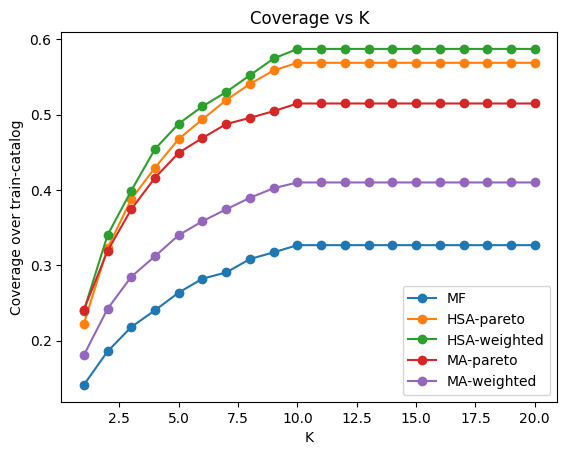

In [21]:
# max_k = 20
# mf_cov = coverage_curve(mf_recs_df, catalog_items=all_train_items, max_k=max_k)
# ea_cov = coverage_curve(ea_recs_df, catalog_items=all_train_items, max_k=max_k)

# plt.figure()
# plt.plot(range(1, max_k+1), mf_cov, marker="o", label="MF")
# plt.plot(range(1, max_k+1), ea_cov, marker="o", label="EA")
# plt.xlabel("K")
# plt.ylabel("Coverage over train-catalog")
# plt.title("Coverage vs K")
# plt.legend()
# plt.show()

max_k = 20

plt.figure()

# MF
mf_cov = coverage_curve(mf_recs_df, catalog_items=all_train_items, max_k=max_k)
plt.plot(range(1, max_k+1), mf_cov, marker="o", label="MF")

# 4 EA settings
for (algo_name, mo_mode), df in dfs.items():
    cov = coverage_curve(df, catalog_items=all_train_items, max_k=max_k)
    plt.plot(range(1, max_k+1), cov, marker="o", label=f"{algo_name}-{mo_mode}")

plt.xlabel("K")
plt.ylabel("Coverage over train-catalog")
plt.title("Coverage vs K")
plt.legend()
plt.show()



***Exposure inequality: log-log exposure + Lorenz curve***

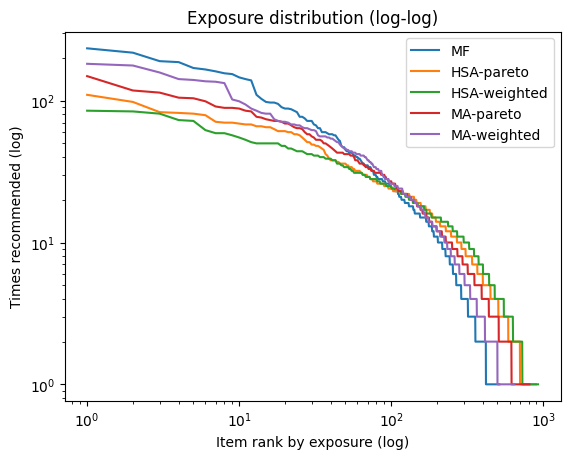

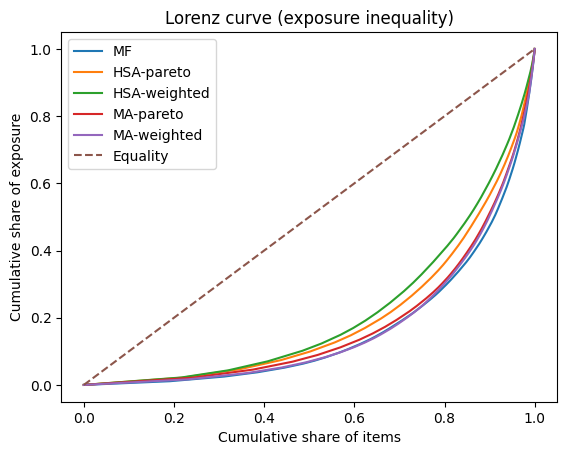

In [22]:
# mf_exp = exposure_counts(mf_recs_df, K=K)
# ea_exp = exposure_counts(ea_recs_df, K=K)

# # Log-log exposure (popular items get recommended a lot?)
# mf_vals = mf_exp.sort_values(ascending=False).to_numpy()
# ea_vals = ea_exp.sort_values(ascending=False).to_numpy()

# plt.figure()
# plt.plot(range(1, len(mf_vals)+1), mf_vals, label="MF")
# plt.plot(range(1, len(ea_vals)+1), ea_vals, label="EA")
# plt.xscale("log")
# plt.yscale("log")
# plt.xlabel("Item rank by exposure (log)")
# plt.ylabel("Times recommended (log)")
# plt.title("Exposure distribution (log-log)")
# plt.legend()
# plt.show()

plt.figure()

# MF
mf_exp = exposure_counts(mf_recs_df, K=K)
mf_vals = mf_exp.sort_values(ascending=False).to_numpy()
plt.plot(range(1, len(mf_vals)+1), mf_vals, label="MF")

# EA settings
for (algo_name, mo_mode), df in dfs.items():
    exp = exposure_counts(df, K=K)
    vals = exp.sort_values(ascending=False).to_numpy()
    plt.plot(range(1, len(vals)+1), vals, label=f"{algo_name}-{mo_mode}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("Item rank by exposure (log)")
plt.ylabel("Times recommended (log)")
plt.title("Exposure distribution (log-log)")
plt.legend()
plt.show()


# # Lorenz curve
# mf_l = lorenz_curve_from_counts(mf_exp.values)
# ea_l = lorenz_curve_from_counts(ea_exp.values)

# plt.figure()
# plt.plot(np.linspace(0,1,len(mf_l)), mf_l, label="MF")
# plt.plot(np.linspace(0,1,len(ea_l)), ea_l, label="EA")
# plt.plot([0,1],[0,1], linestyle="--", label="Equality")
# plt.xlabel("Cumulative share of items")
# plt.ylabel("Cumulative share of exposure")
# plt.title("Lorenz curve (exposure inequality)")
# plt.legend()
# plt.show()

plt.figure()

# MF
mf_exp = exposure_counts(mf_recs_df, K=K)
mf_l = lorenz_curve_from_counts(mf_exp.values)
plt.plot(np.linspace(0,1,len(mf_l)), mf_l, label="MF")

# EA settings
for (algo_name, mo_mode), df in dfs.items():
    exp = exposure_counts(df, K=K)
    l = lorenz_curve_from_counts(exp.values)
    plt.plot(np.linspace(0,1,len(l)), l, label=f"{algo_name}-{mo_mode}")

# Equality line
plt.plot([0,1],[0,1], linestyle="--", label="Equality")

plt.xlabel("Cumulative share of items")
plt.ylabel("Cumulative share of exposure")
plt.title("Lorenz curve (exposure inequality)")
plt.legend()
plt.show()



***Genre distribution in recommended lists (what genres does model expose?)***

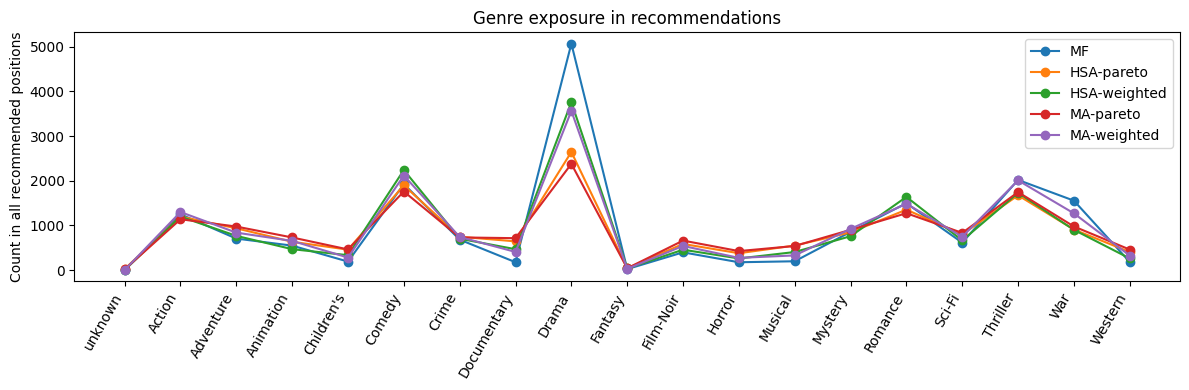

In [23]:
# def genre_hist(recs_df, K, item_genres):
#     tmp = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K)
#     counts = Counter()
#     for iid in tmp["item_id"].astype(int).tolist():
#         v = item_genres.get(iid)
#         if v is None:
#             continue
#         for gid in np.where(v == 1)[0]:
#             counts[int(gid)] += 1
#     return counts

# mf_g = genre_hist(mf_recs_df, K, item_genres)
# ea_g = genre_hist(ea_recs_df, K, item_genres)

# # Align to 0..18
# x = np.arange(19)
# mf_y = np.array([mf_g.get(i,0) for i in x])
# ea_y = np.array([ea_g.get(i,0) for i in x])

# # Genre names
# genre_name = dict(zip(genres_clean["genre_id"].astype(int), genres_clean["genre"].astype(str)))
# labels = [genre_name.get(i, str(i)) for i in x]

# plt.figure(figsize=(12,4))
# plt.plot(x, mf_y, marker="o", label="MF")
# plt.plot(x, ea_y, marker="o", label="EA")
# plt.xticks(x, labels, rotation=60, ha="right")
# plt.ylabel("Count in all recommended positions")
# plt.title("Genre exposure in recommendations")
# plt.legend()
# plt.tight_layout()
# plt.show()


from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

def genre_hist(recs_df, K, item_genres):
    tmp = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K)
    counts = Counter()
    for iid in tmp["item_id"].astype(int).tolist():
        v = item_genres.get(iid)
        if v is None:
            continue
        for gid in np.where(v == 1)[0]:
            counts[int(gid)] += 1
    return counts

# Align to 0..18
x = np.arange(19)

# Genre names
genre_name = dict(zip(genres_clean["genre_id"].astype(int), genres_clean["genre"].astype(str)))
labels = [genre_name.get(i, str(i)) for i in x]

plt.figure(figsize=(12,4))

# MF
mf_g = genre_hist(mf_recs_df, K, item_genres)
mf_y = np.array([mf_g.get(i,0) for i in x])
plt.plot(x, mf_y, marker="o", label="MF")

# EA settings
for (algo_name, mo_mode), df in dfs.items():
    g = genre_hist(df, K, item_genres)
    y = np.array([g.get(i,0) for i in x])
    plt.plot(x, y, marker="o", label=f"{algo_name}-{mo_mode}")

plt.xticks(x, labels, rotation=60, ha="right")
plt.ylabel("Count in all recommended positions")
plt.title("Genre exposure in recommendations")
plt.legend()
plt.tight_layout()
plt.show()


***Qualitative: show one user’s MF vs EA lists (titles + genres)***

In [24]:
# def genre_names_for_item(item_id, genres_clean, item_genres):
#     """
#     item_id: int (movie_id)
#     genres_clean: لیست نام ژانرها به همان ترتیب ستون‌های ژانری
#     item_genres: DataFrame یا dict/Series که برای هر movie_id بردار ژانر (0/1) می‌دهد

#     خروجی: لیست نام ژانرهای فعال
#     """
#     # حالت DataFrame با index=movie_id
#     if hasattr(item_genres, "loc"):
#         if int(item_id) not in item_genres.index:
#             return []
#         vec = item_genres.loc[int(item_id)].values
#     else:
#         # حالت dict: item_genres[movie_id] = vector
#         vec = item_genres.get(int(item_id), None)
#         if vec is None:
#             return []

#     vec = list(vec)
#     names = [genres_clean[i] for i, v in enumerate(vec) if int(v) == 1]
#     return names

## -----------------------------------------------------------------------------------------

# # --- Build robust mapping: movie_id -> list of genre names (no pandas index issues) ---

# # این‌ها باید در نوت‌بوک موجود باشند:
# # items_raw: دیتافریم u.item (یا مشابه) که movie_id و ستون‌های ژانر را دارد
# # genres_clean: لیست نام ژانرها به همان ترتیب ستون‌های ژانری در items_raw

# genre_cols = genres_clean  # نام ژانرها (مثلاً 19 ژانر)

# # اگر ستون‌های ژانر در items_raw دقیقاً همین نام‌ها نیستند، این خط را اصلاح کن:
# # genre_cols = [...]  # لیست ستون‌های ژانری واقعی در items_raw

# movieid_to_genres = {}
# for row in items_raw[["movie_id"] + genre_cols].itertuples(index=False):
#     mid = int(row[0])
#     flags = row[1:]
#     gnames = [genre_cols[i] for i, v in enumerate(flags) if int(v) == 1]
#     movieid_to_genres[mid] = gnames

# def genre_names_for_item(item_id):
#     return movieid_to_genres.get(int(item_id), [])

## -----------------------------------------------------------------------------------------

# --- Robust genre column detection + mapping movie_id -> genre names ---

import numpy as np
import pandas as pd

def genre_names_for_item_simple(iid, genres_clean_df, item_genres_dict):
    """
    iid: movie_id
    genres_clean_df: DataFrame با ستون‌های [genre_id, genre]
    item_genres_dict: dict[movie_id] -> np.array(19,) (0/1)

    خروجی: لیست نام ژانرهای فعال برای آن آیتم
    """
    v = item_genres_dict.get(int(iid))
    if v is None:
        return []

    idxs = np.where(np.asarray(v) == 1)[0].tolist()

    # اگر genres_clean_df ساختار درست داشته باشد، اسم ژانرها را برگردان
    if isinstance(genres_clean_df, pd.DataFrame) and {"genre_id","genre"}.issubset(genres_clean_df.columns):
        out = []
        for g in idxs:
            m = genres_clean_df.loc[genres_clean_df["genre_id"].astype(int) == int(g), "genre"]
            out.append(str(m.iloc[0]) if len(m) else str(g))
        return out

    # fallback
    return [str(g) for g in idxs]


def show_user_lists(uid, K=10):
    """
    برای یک کاربر، ۵ لیست نشان می‌دهد:
    MF baseline + (HSA/MA × pareto/weighted)
    نیازمندی‌ها:
      - mf_recs_df موجود باشد
      - dfs دیکشنری خروجی ۴ حالت باشد
      - items_raw شامل ستون‌های movie_id و title باشد
    """
    rows_all = []

    # یک تابع کمکی برای تبدیل لیست آیتم‌ها به ردیف‌های جدول
    def to_rows(lst, name):
        rows = []
        for rank, iid in enumerate(lst[:K], start=1):
            # عنوان فیلم
            title_s = items_raw.loc[items_raw["movie_id"] == int(iid), "title"]
            title = title_s.iloc[0] if len(title_s) else "UNKNOWN"

            # ژانرها
            gnames = genre_names_for_item_simple(iid, genres_clean, item_genres)

            rows.append({
                "model": name,
                "rank": int(rank),
                "item_id": int(iid),
                "title": title,
                "genres": ", ".join(gnames)
            })
        return rows

    # 1) MF baseline
    mf_lists_local = build_user_lists(mf_recs_df, K)
    mf_list = mf_lists_local.get(uid, [])
    rows_all += to_rows(mf_list, "MF baseline")

    # 2) 4 EA modes
    for (algo_name, mo_mode), df in dfs.items():
        lists = build_user_lists(df, K)
        ea_list = lists.get(uid, [])
        rows_all += to_rows(ea_list, f"{algo_name}-{mo_mode}")

    display(pd.DataFrame(rows_all))


# نمونه اجرا
example_user = int(sorted(build_user_lists(mf_recs_df, K).index)[0])
print("Example user:", example_user)
show_user_lists(example_user, K=K)


Example user: 1


,model,rank,item_id,title,genres
0,MF baseline,1,511,Lawrence of Arabia (1962),"Adventure, War"
1,MF baseline,2,302,L.A. Confidential (1997),"Crime, Film-Noir, Mystery, Thriller"
2,MF baseline,3,357,One Flew Over the Cuckoo's Nest (1975),Drama
3,MF baseline,4,709,Strictly Ballroom (1992),"Comedy, Romance"
4,MF baseline,5,318,Schindler's List (1993),"Drama, War"
5,MF baseline,6,657,"Manchurian Candidate, The (1962)","Film-Noir, Thriller"
6,MF baseline,7,647,Ran (1985),"Drama, War"
7,MF baseline,8,408,"Close Shave, A (1995)","Animation, Comedy, Thriller"
8,MF baseline,9,963,Some Folks Call It a Sling Blade (1993),"Drama, Thriller"
9,MF baseline,10,474,Dr. Strangelove or: How I Learned to Stop Worr...,"Sci-Fi, War"


In [25]:
example_user = sorted(mf_lists.index)[1]
print("Example user:", example_user)
show_user_lists(example_user, K=K)

Example user: 2


,model,rank,item_id,title,genres
0,MF baseline,1,604,It Happened One Night (1934),Comedy
1,MF baseline,2,603,Rear Window (1954),"Mystery, Thriller"
2,MF baseline,3,246,Chasing Amy (1997),"Drama, Romance"
3,MF baseline,4,588,Beauty and the Beast (1991),"Animation, Children's, Musical"
4,MF baseline,5,98,"Silence of the Lambs, The (1991)","Drama, Thriller"
5,MF baseline,6,189,"Grand Day Out, A (1992)","Animation, Comedy"
6,MF baseline,7,488,Sunset Blvd. (1950),Film-Noir
7,MF baseline,8,511,Lawrence of Arabia (1962),"Adventure, War"
8,MF baseline,9,192,Raging Bull (1980),Drama
9,MF baseline,10,1194,Once Were Warriors (1994),"Crime, Drama"


In [26]:
example_user = sorted(mf_lists.index)[2]
print("Example user:", example_user)
show_user_lists(example_user, K=K)

Example user: 3


,model,rank,item_id,title,genres
0,MF baseline,1,136,Mr. Smith Goes to Washington (1939),Drama
1,MF baseline,2,483,Casablanca (1942),"Drama, Romance, War"
2,MF baseline,3,657,"Manchurian Candidate, The (1962)","Film-Noir, Thriller"
3,MF baseline,4,114,Wallace & Gromit: The Best of Aardman Animatio...,Animation
4,MF baseline,5,48,Hoop Dreams (1994),Documentary
5,MF baseline,6,285,Secrets & Lies (1996),Drama
6,MF baseline,7,12,"Usual Suspects, The (1995)","Crime, Thriller"
7,MF baseline,8,187,"Godfather: Part II, The (1974)","Action, Crime, Drama"
8,MF baseline,9,228,Star Trek: The Wrath of Khan (1982),"Action, Adventure, Sci-Fi"
9,MF baseline,10,127,"Godfather, The (1972)","Action, Crime, Drama"


In [27]:
example_user = sorted(mf_lists.index)[3]
print("Example user:", example_user)
show_user_lists(example_user, K=K)

Example user: 4


,model,rank,item_id,title,genres
0,MF baseline,1,191,Amadeus (1984),"Drama, Mystery"
1,MF baseline,2,519,"Treasure of the Sierra Madre, The (1948)",Adventure
2,MF baseline,3,318,Schindler's List (1993),"Drama, War"
3,MF baseline,4,313,Titanic (1997),"Action, Drama, Romance"
4,MF baseline,5,223,Sling Blade (1996),"Drama, Thriller"
5,MF baseline,6,483,Casablanca (1942),"Drama, Romance, War"
6,MF baseline,7,435,Butch Cassidy and the Sundance Kid (1969),"Action, Comedy, Western"
7,MF baseline,8,427,To Kill a Mockingbird (1962),Drama
8,MF baseline,9,513,"Third Man, The (1949)","Mystery, Thriller"
9,MF baseline,10,1194,Once Were Warriors (1994),"Crime, Drama"


In [28]:
example_user = sorted(mf_lists.index)[4]
print("Example user:", example_user)
show_user_lists(example_user, K=K)

Example user: 5


,model,rank,item_id,title,genres
0,MF baseline,1,175,Brazil (1985),Sci-Fi
1,MF baseline,2,179,"Clockwork Orange, A (1971)",Sci-Fi
2,MF baseline,3,19,Antonia's Line (1995),Drama
3,MF baseline,4,511,Lawrence of Arabia (1962),"Adventure, War"
4,MF baseline,5,194,"Sting, The (1973)","Comedy, Crime"
5,MF baseline,6,483,Casablanca (1942),"Drama, Romance, War"
6,MF baseline,7,648,"Quiet Man, The (1952)","Comedy, Romance"
7,MF baseline,8,286,"English Patient, The (1996)","Drama, Romance, War"
8,MF baseline,9,516,Local Hero (1983),Comedy
9,MF baseline,10,474,Dr. Strangelove or: How I Learned to Stop Worr...,"Sci-Fi, War"
